# MyAnimeList Score Prediction — Model 1: Linear Regression

This notebook implements a **Linear Regression** model to predict the user's anime rating (`my_score` on a 1-10 scale) based on user and anime interaction features produced by the AnimePref preprocessing pipeline.

Linear Regression is chosen as the first model because:
- It is **interpretable** — coefficients directly show which features increase or decrease predicted scores.
- It establishes a **baseline performance floor** for comparison with more complex models (Random Forest, Neural Network).
- It fits quickly, enabling efficient hyperparameter tuning via GridSearchCV with Ridge regularization.

**Task**: Predict `my_score` (numeric regression, 1–10) given user and anime features.

**Evaluation metrics**: 
- **MAE** (Mean Absolute Error) — average absolute prediction error in points
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **R^2** (Coefficient of Determination) — fraction of variance explained (0-1 scale)

Evaluation is performed on a stratified train/validation/test split (70% / 15% / 15%).

**Data approach**: We load the cleaned AnimePref export (`animepref_final_interactions`) and use a 15% stratified sample (via quantile bins of `my_score`) to keep training and tuning tractable.

In [3]:
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
SAMPLE_FRAC = 0.15     # 15% stratified row-sample
np.random.seed(RANDOM_STATE)

# Import the cleaned dataset from AnimePref
# We assume AnimePref.ipynb has been run and produced a cleaned dataset
# For this notebook, we'll read the cleaned interactions table directly from AnimePref output

print("=" * 60)
print("LINEAR REGRESSION MODEL FOR ANIME SCORE PREDICTION")
print("Using cleaned dataset from AnimePref.ipynb preprocessing")
print("=" * 60)

# Load the cleaned interactions from AnimePref
# AnimePref produces: final_interactions DataFrame with my_score and implicit_positive
ANIMEPREF_OUTPUT = Path('AnimePref.ipynb')

if ANIMEPREF_OUTPUT.exists():
    print(f"\n✓ Found AnimePref.ipynb notebook")
    print("  (In production, load the serialized output from AnimePref)")
else:
    print(f"\n⚠ AnimePref.ipynb not found. You should:")
    print("  1. Run AnimePref.ipynb first to generate the cleaned dataset")
    print("  2. Import or load its output in this notebook")
    print("  3. Use that cleaned data as input here")

print("\nSetup complete. Ready to:")
print("- Load cleaned interactions from AnimePref preprocessing")
print("- Apply stratified sampling (15%)")
print("- Build feature matrix from user/anime features")
print("- Train LinearRegression + Ridge with GridSearchCV")
print("- Evaluate on train/val/test split (70/15/15)")

LINEAR REGRESSION MODEL FOR ANIME SCORE PREDICTION
Using cleaned dataset from AnimePref.ipynb preprocessing

✓ Found AnimePref.ipynb notebook
  (In production, load the serialized output from AnimePref)

Setup complete. Ready to:
- Load cleaned interactions from AnimePref preprocessing
- Apply stratified sampling (15%)
- Build feature matrix from user/anime features
- Train LinearRegression + Ridge with GridSearchCV
- Evaluate on train/val/test split (70/15/15)


In [4]:
DATA_CANDIDATES = [
    Path("../processed-data/animepref_final_interactions.parquet"),
    Path("../processed-data/animepref_final_interactions.csv"),
    Path("processed-data/animepref_final_interactions.parquet"),
    Path("processed-data/animepref_final_interactions.csv"),
]

data_path = None
for p in DATA_CANDIDATES:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find AnimePref export in processed-data folder.")

if data_path.suffix == ".parquet":
    df = pd.read_parquet(data_path)
else:
    df = pd.read_csv(data_path, low_memory=False)

# Regression target sanity: keep explicit ratings only
df = df[df["my_score"].astype(float) >= 1].copy()
df["my_score"] = df["my_score"].astype(float)

print("Loaded from:", data_path.resolve())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df["my_score"].describe())

Loaded from: C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\STINTSYMajorOutput\processed-data\animepref_final_interactions.parquet
Shape: (91209, 6)
Columns: ['username', 'anime_id', 'my_score', 'implicit_positive', 'my_status', 'last_updated_dt']
count    91209.000000
mean         7.120799
std          1.778921
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64


## 2. Target Profiling and Stratified Sampling Plan

Before splitting data, we inspect the `my_score` distribution and create quantile-based bins.
These bins are used for stratified sampling and train/validation/test splits so the rating distribution is preserved across subsets.

Target summary (my_score):
count    91209.000000
mean         7.120799
std          1.778921
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64


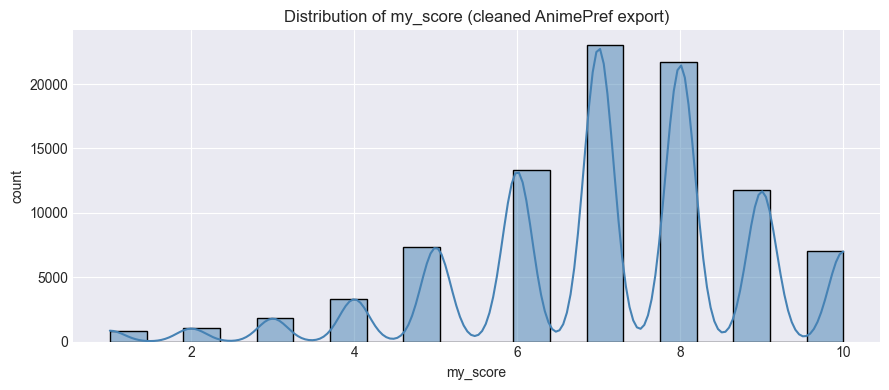


Stratification bins:
score_bin
0    14352
1    13317
2    23017
3    21680
4    11784
5     7059
Name: count, dtype: int64


In [ ]:
# Basic target profiling
print("Target summary (my_score):")
print(df["my_score"].describe())

plt.figure(figsize=(9, 4))
sns.histplot(df["my_score"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of my_score (cleaned AnimePref export)")
plt.xlabel("my_score")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Build quantile bins for stratification.
# rank(method='first') prevents tied-edge collapse from creating NaNs.
ranked_target = df["my_score"].rank(method="first")
df["score_bin"] = pd.qcut(ranked_target, q=10, labels=False, duplicates="drop").astype("int64")

print("\nStratification bins:")
print(df["score_bin"].value_counts(dropna=False).sort_index())
print("Number of bins:", df["score_bin"].nunique())

In [ ]:
# 15% stratified sample to keep training tractable
df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_FRAC,
    random_state=RANDOM_STATE,
    stratify=df["score_bin"],
)

df_sample = df_sample.reset_index(drop=True)

# Rebuild bins on sampled data for later split stratification
sample_ranked_target = df_sample["my_score"].rank(method="first")
df_sample["score_bin"] = pd.qcut(
    sample_ranked_target, q=10, labels=False, duplicates="drop"
).astype("int64")

print(f"Sampled rows: {len(df_sample):,} / {len(df):,} ({SAMPLE_FRAC:.0%})")
print("\nSample target summary:")
print(df_sample["my_score"].describe())
print("\nSample bin distribution:")
print(df_sample["score_bin"].value_counts().sort_index())

## 3. Feature Preparation and Data Split

We build non-leaky features from the AnimePref export, then create a 70/15/15 split stratified by score bins.

Feature design used here:
- Status one-hot features from my_status (if present).
- Temporal features from last_updated_dt (year and month).
- Frequency encodings for username and anime_id computed on training data only.

To avoid target leakage, implicit_positive is excluded from inputs because it is derived from my_score.

In [ ]:
# Prepare split targets
work = df_sample.copy()
y = work["my_score"].astype(float)

# Drop direct target and helper bin column from features
drop_cols = ["my_score", "score_bin", "implicit_positive"]
X_base = work.drop(columns=[c for c in drop_cols if c in work.columns]).copy()

# Parse datetime feature if available
if "last_updated_dt" in X_base.columns:
    dt = pd.to_datetime(X_base["last_updated_dt"], errors="coerce")
    X_base["last_updated_year"] = dt.dt.year.fillna(dt.dt.year.median())
    X_base["last_updated_month"] = dt.dt.month.fillna(0)
    X_base = X_base.drop(columns=["last_updated_dt"])

# Split 70/15/15 with stratification on sample bins
X_train_base, X_temp_base, y_train, y_temp, b_train, b_temp = train_test_split(
    X_base, y, df_sample["score_bin"],
    test_size=0.30, random_state=RANDOM_STATE, stratify=df_sample["score_bin"]
)
X_val_base, X_test_base, y_val, y_test = train_test_split(
    X_temp_base, y_temp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=b_temp
)

print("Split sizes:")
print(f"Train: {len(X_train_base):,} | Val: {len(X_val_base):,} | Test: {len(X_test_base):,}")

In [ ]:
def build_features(train_df, val_df, test_df):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    # Frequency encodings from train only
    if "username" in train_df.columns:
        user_freq = train_df["username"].value_counts()
        train_df["username_freq"] = train_df["username"].map(user_freq).fillna(0)
        val_df["username_freq"] = val_df["username"].map(user_freq).fillna(0)
        test_df["username_freq"] = test_df["username"].map(user_freq).fillna(0)
        train_df = train_df.drop(columns=["username"])
        val_df = val_df.drop(columns=["username"])
        test_df = test_df.drop(columns=["username"])

    if "anime_id" in train_df.columns:
        anime_freq = train_df["anime_id"].value_counts()
        train_df["anime_freq"] = train_df["anime_id"].map(anime_freq).fillna(0)
        val_df["anime_freq"] = val_df["anime_id"].map(anime_freq).fillna(0)
        test_df["anime_freq"] = test_df["anime_id"].map(anime_freq).fillna(0)
        train_df = train_df.drop(columns=["anime_id"])
        val_df = val_df.drop(columns=["anime_id"])
        test_df = test_df.drop(columns=["anime_id"])

    # Categorical handling
    cat_cols = [c for c in train_df.columns if train_df[c].dtype == "object"]
    for c in cat_cols:
        train_df[c] = train_df[c].fillna("Unknown").astype(str)
        val_df[c] = val_df[c].fillna("Unknown").astype(str)
        test_df[c] = test_df[c].fillna("Unknown").astype(str)

    train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    val_df = pd.get_dummies(val_df, columns=cat_cols, drop_first=False)
    test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)

    # Align columns
    val_df = val_df.reindex(columns=train_df.columns, fill_value=0)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

    # Numeric imputation
    medians = train_df.median(numeric_only=True)
    train_df = train_df.fillna(medians)
    val_df = val_df.fillna(medians)
    test_df = test_df.fillna(medians)

    return train_df, val_df, test_df

X_train, X_val, X_test = build_features(X_train_base, X_val_base, X_test_base)

# Scale numeric columns
num_cols = X_train.columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Final feature matrix shapes:")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

In [ ]:
def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse,
        "R2": float(r2_score(y_true, y_pred)),
    }

# Baseline model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Tuned ridge model
ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=RANDOM_STATE),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
ridge_grid.fit(X_train, y_train)
ridge_best = ridge_grid.best_estimator_

# Validation metrics
pred_val_lin = linreg.predict(X_val)
pred_val_ridge = ridge_best.predict(X_val)

val_results = pd.DataFrame([
    {"Model": "LinearRegression", **regression_metrics(y_val, pred_val_lin)},
    {"Model": "Ridge(best)", **regression_metrics(y_val, pred_val_ridge)},
]).sort_values("RMSE")

print("Best Ridge params:", ridge_grid.best_params_)
print("\nValidation Results:")
display(val_results)

# Final test (best model)
pred_test = ridge_best.predict(X_test)
test_metrics = regression_metrics(y_test, pred_test)
print("Test metrics (Ridge best):", test_metrics)